# Regressão Logística: Previsão de Cancelamento de Clientes (Churn)

**Atividade 7 — Trabalho em grupo**

Este notebook reproduz, em formato executável, a análise apresentada no relatório em LaTeX, cobrindo todos os itens pedidos na atividade: descrição do problema, descrição e tratamento dos dados, análise exploratória, divisão treino/teste, ajuste do modelo de regressão logística, interpretação de coeficientes e razões de chance, avaliação de significância, Curva ROC/AUC, matriz de confusão e conclusões.


## 1. Introdução e Objetivo

O cancelamento de clientes, conhecido no meio empresarial como *churn*, é um dos principais problemas enfrentados por empresas que possuem serviços de assinatura, como operadoras de telecomunicações. Reter um cliente já existente costuma ser mais barato do que conquistar um novo, de modo que entender quais fatores levam um cliente a cancelar o serviço tem valor direto para a tomada de decisão da empresa.

Este trabalho utiliza o conjunto de dados **Telco Customer Churn** (Kaggle), composto por 7043 clientes de uma empresa de telecomunicações, com informações cadastrais, serviços contratados, forma de pagamento e status de cancelamento.

**Objetivo:** ajustar um modelo de regressão logística para estimar a probabilidade de um cliente cancelar o serviço (*churn*), a partir de suas características cadastrais, dos serviços contratados e das condições do contrato. Pretende-se também avaliar quais covariáveis são significativas, interpretar seus efeitos por meio das razões de chance (*odds ratios*), e medir a capacidade preditiva do modelo em dados não usados na sua construção (amostra de teste).


In [29]:
# Pacotes utilizados ao longo de toda a análise
library(dplyr)      # manipulação de dados
library(ggplot2)     # gráficos
library(caret)        # particionamento treino/teste e matriz de confusão
library(pROC)          # curva ROC e AUC

set.seed(123) # reprodutibilidade (treino/teste)


## 2. Descrição do Conjunto de Dados

O banco de dados original possui 7043 linhas e 21 colunas.

**Variável resposta:** `Churn`, que indica se o cliente cancelou o serviço (`Yes`) ou permaneceu com a empresa (`No`). Será recodificada como binária numérica (1 = cancelou, 0 = não cancelou).

**Covariáveis utilizadas:**

- `gender`, `SeniorCitizen`, `Partner`, `Dependents` — características cadastrais;
- `tenure` — número de meses que o cliente permanece na empresa;
- `PhoneService`, `MultipleLines` — serviço de telefonia;
- `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` — serviço de internet e complementos;
- `Contract`, `PaperlessBilling`, `PaymentMethod` — condições contratuais;
- `MonthlyCharges`, `TotalCharges` — valores cobrados.

A coluna `customerID` foi removida por se tratar apenas de um identificador do cliente, sem relação com a chance de cancelamento.


In [30]:
# Leitura dos dados
dados <- read.csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", stringsAsFactors = FALSE)

head(dados)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,⋯,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,⋯,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,⋯,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
6,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,⋯,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes


In [31]:
dim(dados)   # número de linhas e colunas
str(dados)   # tipos das variáveis


[1] 7043   21

'data.frame':	7043 obs. of  21 variables:
 $ customerID      : chr  "7590-VHVEG" "5575-GNVDE" "3668-QPYBK" "7795-CFOCW" ...
 $ gender          : chr  "Female" "Male" "Male" "Male" ...
 $ SeniorCitizen   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner         : chr  "Yes" "No" "No" "No" ...
 $ Dependents      : chr  "No" "No" "No" "No" ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : chr  "No" "Yes" "Yes" "No" ...
 $ MultipleLines   : chr  "No phone service" "No" "No" "No phone service" ...
 $ InternetService : chr  "DSL" "DSL" "DSL" "DSL" ...
 $ OnlineSecurity  : chr  "No" "Yes" "Yes" "Yes" ...
 $ OnlineBackup    : chr  "Yes" "No" "Yes" "No" ...
 $ DeviceProtection: chr  "No" "Yes" "No" "Yes" ...
 $ TechSupport     : chr  "No" "No" "No" "Yes" ...
 $ StreamingTV     : chr  "No" "No" "No" "No" ...
 $ StreamingMovies : chr  "No" "No" "No" "No" ...
 $ Contract        : chr  "Month-to-month" "One year" "Month-to-month" "One year" ...
 $ PaperlessBilling: chr  "Yes"

### Recodificação da variável resposta

A variável `Churn` é recodificada para 1 (cancelou) e 0 (não cancelou), e sua distribuição é verificada.


In [32]:
dados$Churn <- ifelse(dados$Churn == "Yes", 1, 0)

table(dados$Churn)
prop.table(table(dados$Churn))



   0    1 
5174 1869 


        0         1 
0.7346301 0.2653699 

Do total de 7043 clientes, 5174 (73,5%) não cancelaram o serviço e 1869 (26,5%) cancelaram. Trata-se, portanto, de uma base moderadamente desbalanceada — ponto que será retomado na divisão da amostra e na escolha do ponto de corte do modelo.


In [33]:
# Remoção do identificador do cliente (não é covariável)
dados$customerID <- NULL


### Tratamento dos dados

Ao importar o banco, a coluna `TotalCharges` apresenta valores faltantes. Investigamos essas linhas antes de decidir como tratá-las.


In [34]:
sum(is.na(dados$TotalCharges))

dados[is.na(dados$TotalCharges), c("tenure", "MonthlyCharges", "TotalCharges")]


[1] 11

,tenure,MonthlyCharges,TotalCharges
,<int>,<dbl>,<dbl>
489,0,52.55,NA
754,0,20.25,NA
937,0,80.85,NA
1083,0,25.75,NA
1341,0,56.05,NA
3332,0,19.85,NA
3827,0,25.35,NA
4381,0,20.00,NA
5219,0,19.70,NA


Todas as 11 linhas com `TotalCharges` faltante correspondem a clientes com `tenure` igual a zero, ou seja, clientes que acabaram de contratar o serviço e ainda não completaram um mês de cobrança. Como o valor faltante é, na prática, implicado pela própria variável `tenure` (cobrança total ainda seria zero), optamos por **imputar o valor 0** nessas observações, em vez de removê-las, preservando a base completa de 7043 clientes.


In [35]:
dados$TotalCharges[is.na(dados$TotalCharges)] <- 0

sum(is.na(dados)) # confirma que não há mais valores faltantes no banco


[1] 0

In [36]:
# Conversão das variáveis de texto para fator (variáveis categóricas)
dados <- dados %>% mutate(across(where(is.character), as.factor))

# SeniorCitizen estava codificada como 0/1; tratamos como fator com rótulos
dados$SeniorCitizen <- factor(dados$SeniorCitizen, labels = c("No", "Yes"))

str(dados)


'data.frame':	7043 obs. of  20 variables:
 $ gender          : Factor w/ 2 levels "Female","Male": 1 2 2 2 1 1 2 1 1 2 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 2 1 1 1 1 1 1 1 2 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 2 1 1 2 ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : Factor w/ 2 levels "No","Yes": 1 2 2 1 2 2 2 1 2 2 ...
 $ MultipleLines   : Factor w/ 3 levels "No","No phone service",..: 2 1 1 2 1 3 3 2 3 1 ...
 $ InternetService : Factor w/ 3 levels "DSL","Fiber optic",..: 1 1 1 1 2 2 2 1 2 1 ...
 $ OnlineSecurity  : Factor w/ 3 levels "No","No internet service",..: 1 3 3 3 1 1 1 3 1 3 ...
 $ OnlineBackup    : Factor w/ 3 levels "No","No internet service",..: 3 1 3 1 1 1 3 1 1 3 ...
 $ DeviceProtection: Factor w/ 3 levels "No","No internet service",..: 1 3 1 3 1 3 1 1 3 1 ...
 $ TechSupport     : Factor w/ 3 levels "No","No int

## 3. Análise Exploratória

### Distribuição da variável resposta


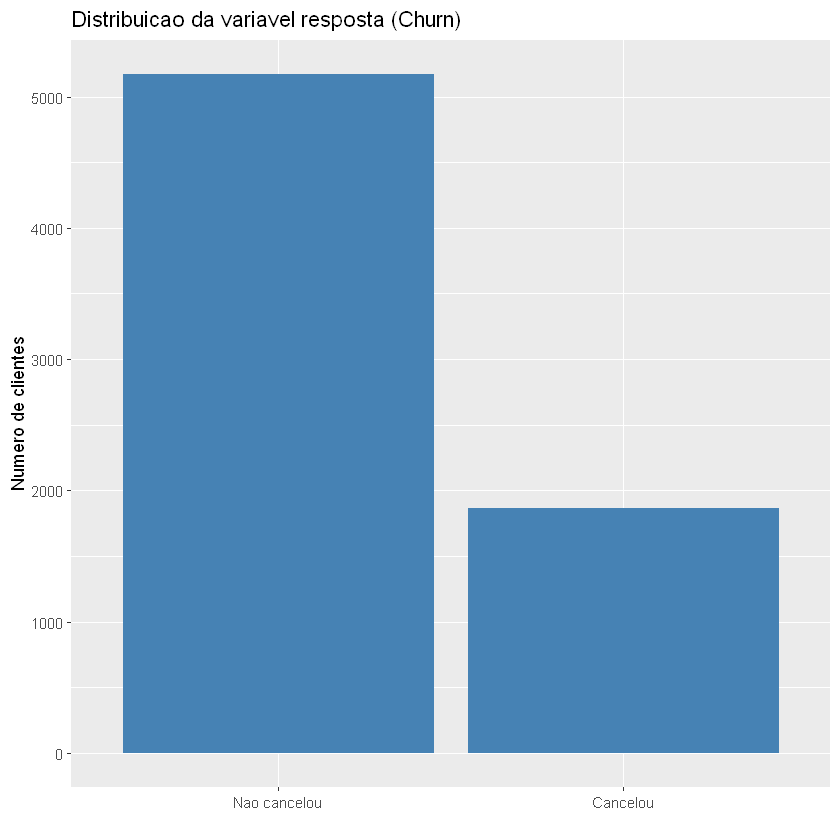

In [37]:
ggplot(dados, aes(x = factor(Churn, labels = c("Nao cancelou", "Cancelou")))) +
  geom_bar(fill = "steelblue") +
  labs(title = "Distribuicao da variavel resposta (Churn)",
       x = "", y = "Numero de clientes")


### Covariáveis numéricas

Resumo estatístico do tempo de contrato (`tenure`), da mensalidade (`MonthlyCharges`) e do total cobrado (`TotalCharges`).


In [38]:
summary(dados[, c("tenure", "MonthlyCharges", "TotalCharges")])


     tenure      MonthlyCharges    TotalCharges   
 Min.   : 0.00   Min.   : 18.25   Min.   :   0.0  
 1st Qu.: 9.00   1st Qu.: 35.50   1st Qu.: 398.6  
 Median :29.00   Median : 70.35   Median :1394.5  
 Mean   :32.37   Mean   : 64.76   Mean   :2279.7  
 3rd Qu.:55.00   3rd Qu.: 89.85   3rd Qu.:3786.6  
 Max.   :72.00   Max.   :118.75   Max.   :8684.8  

### Tempo de contrato e mensalidade por status de churn

Comparamos a distribuição de `tenure` e `MonthlyCharges` entre clientes que cancelaram e clientes que permaneceram com a empresa.


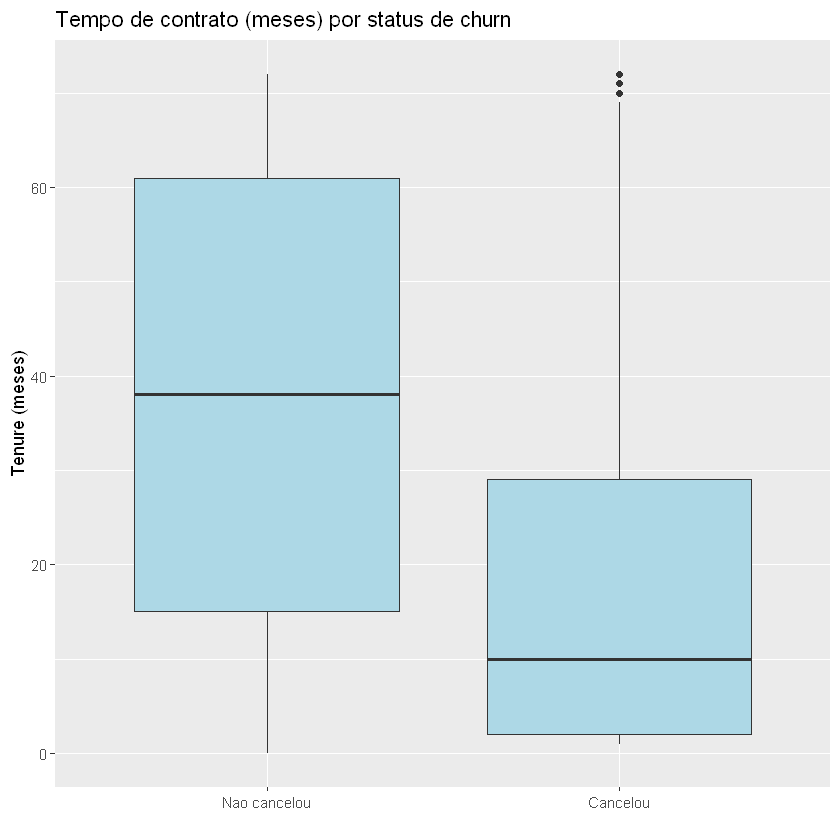

In [39]:
ggplot(dados, aes(x = factor(Churn, labels = c("Nao cancelou", "Cancelou")),
                  y = tenure)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Tempo de contrato (meses) por status de churn",
       x = "", y = "Tenure (meses)")


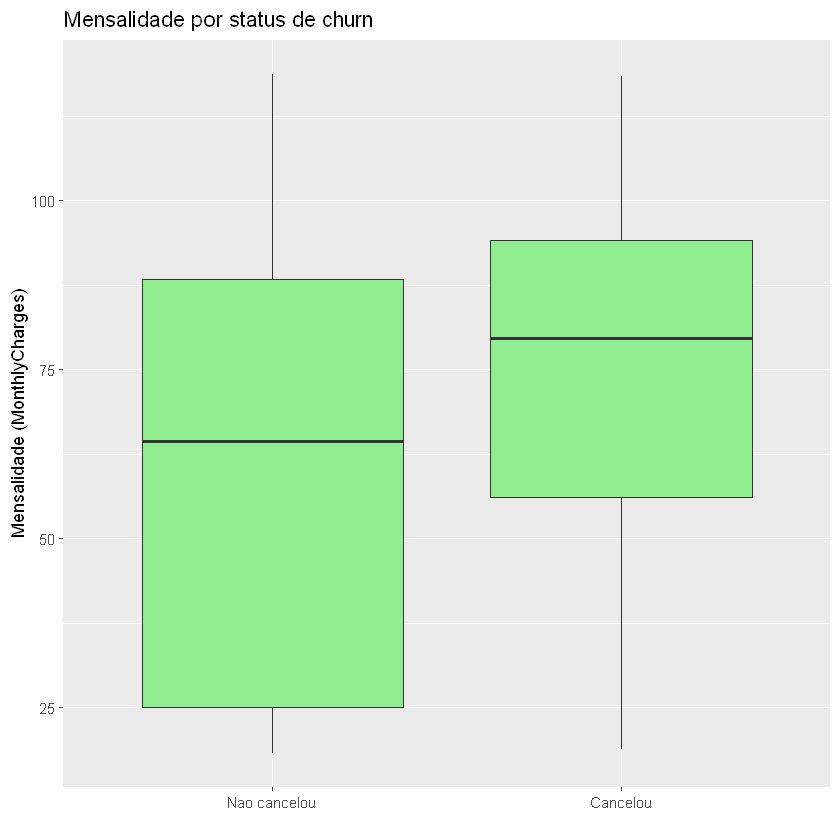

In [40]:
ggplot(dados, aes(x = factor(Churn, labels = c("Nao cancelou", "Cancelou")),
                  y = MonthlyCharges)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Mensalidade por status de churn",
       x = "", y = "Mensalidade (MonthlyCharges)")


Clientes que cancelaram tendem a ter um tempo de contrato menor — o que é esperado, já que clientes mais antigos já demonstraram algum nível de fidelidade ao serviço — e tendem a pagar mensalidades mais altas.

### Covariáveis categóricas: proporção de churn por categoria


                
                          0          1
  Month-to-month 0.57290323 0.42709677
  One year       0.88730482 0.11269518
  Two year       0.97168142 0.02831858

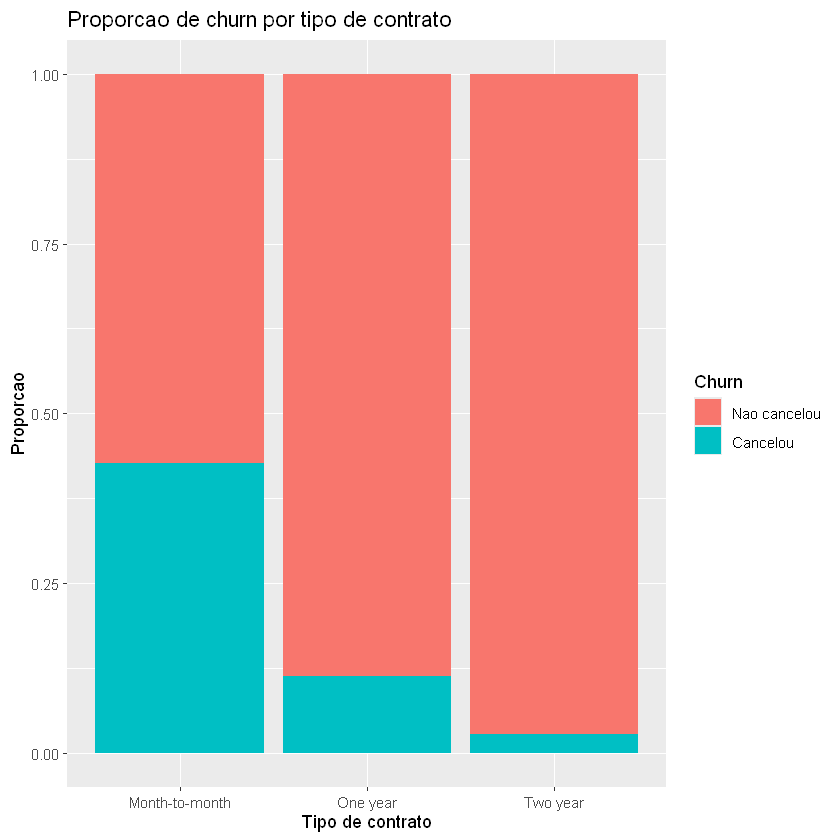

In [41]:
prop.table(table(dados$Contract, dados$Churn), margin = 1)

ggplot(dados, aes(x = Contract, fill = factor(Churn, labels = c("Nao cancelou", "Cancelou")))) +
  geom_bar(position = "fill") +
  labs(title = "Proporcao de churn por tipo de contrato",
       x = "Tipo de contrato", y = "Proporcao", fill = "Churn")


Clientes com contrato mensal (*Month-to-month*) cancelam em uma proporção bem maior (42,7%) do que clientes com contrato de um ano (11,3%) ou de dois anos (2,8%), sugerindo que essa covariável deve ter papel importante no modelo.


                           
                                    0         1
  Bank transfer (automatic) 0.8329016 0.1670984
  Credit card (automatic)   0.8475690 0.1524310
  Electronic check          0.5471459 0.4528541
  Mailed check              0.8089330 0.1910670

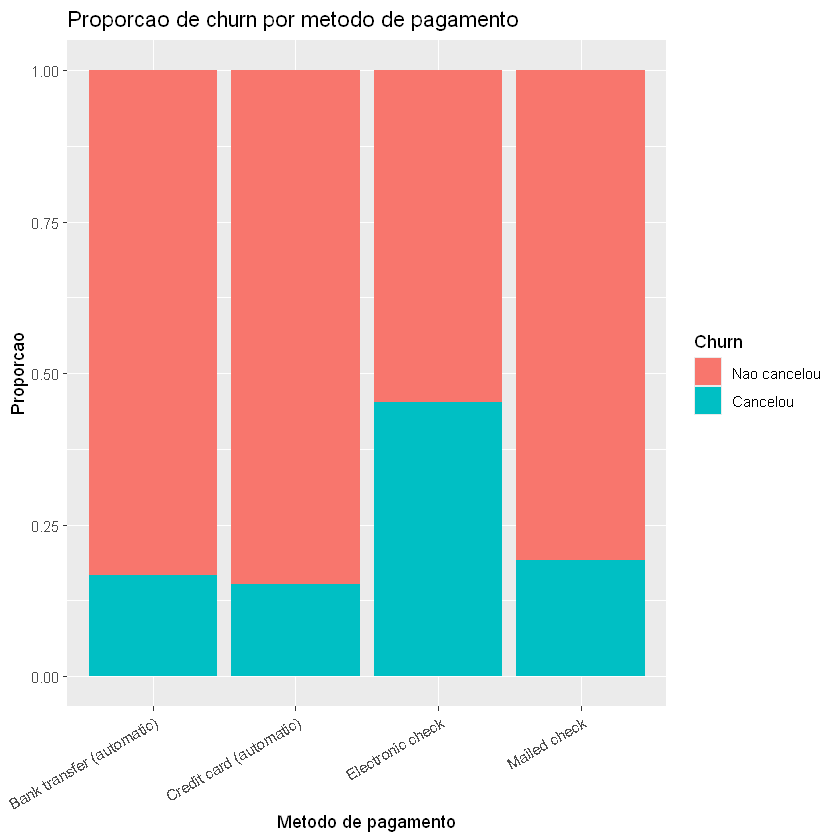

In [42]:
prop.table(table(dados$PaymentMethod, dados$Churn), margin = 1)

ggplot(dados, aes(x = PaymentMethod, fill = factor(Churn, labels = c("Nao cancelou", "Cancelou")))) +
  geom_bar(position = "fill") +
  labs(title = "Proporcao de churn por metodo de pagamento",
       x = "Metodo de pagamento", y = "Proporcao", fill = "Churn") +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))


Clientes que pagam por cheque eletrônico (*Electronic check*) apresentam proporção de cancelamento consideravelmente maior do que os demais métodos, próxima de 45%.


## 4. Divisão da Amostra (Treino e Teste)

Como a variável resposta é desbalanceada (73,5% x 26,5%), a divisão entre treino e teste é feita de forma **estratificada**, e não por amostragem aleatória simples. A estratificação garante que a mesma proporção de cancelamento seja preservada tanto na amostra de treino quanto na amostra de teste, evitando que uma divisão aleatória concentre, por acaso, mais casos de churn em um dos dois conjuntos.

Foi adotada a proporção de 70% dos dados para treino e 30% para teste.


In [43]:
indices_treino <- createDataPartition(dados$Churn, p = 0.7, list = FALSE)

treino <- dados[indices_treino, ]
teste  <- dados[-indices_treino, ]

nrow(treino)
nrow(teste)

# Verificando que a proporcao de churn foi preservada em ambas as amostras
prop.table(table(treino$Churn))
prop.table(table(teste$Churn))


[1] 4931

[1] 2112


        0         1 
0.7215575 0.2784425 


        0         1 
0.7651515 0.2348485 

A divisão resultou em 4931 observações na amostra de treino e 2112 observações na amostra de teste, com a proporção de cancelamento preservada em ambos os conjuntos.


## 5. Ajuste do Modelo de Regressão Logística

O modelo é ajustado **exclusivamente na amostra de treino**, utilizando todas as covariáveis disponíveis como ponto de partida (modelo completo).


In [44]:
modelo_completo <- glm(Churn ~ ., data = treino, family = binomial(link = "logit"))
modelo_completo <- update(modelo_completo, . ~ . - TotalCharges)
summary(modelo_completo)



Call:
glm(formula = Churn ~ gender + SeniorCitizen + Partner + Dependents + 
    tenure + PhoneService + MultipleLines + InternetService + 
    OnlineSecurity + OnlineBackup + DeviceProtection + TechSupport + 
    StreamingTV + StreamingMovies + Contract + PaperlessBilling + 
    PaymentMethod + MonthlyCharges, family = binomial(link = "logit"), 
    data = treino)

Coefficients: (7 not defined because of singularities)
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           1.056273   0.959267   1.101  0.27084    
genderMale                           -0.061292   0.076973  -0.796  0.42587    
SeniorCitizenYes                      0.273139   0.100931   2.706  0.00681 ** 
PartnerYes                           -0.030620   0.091444  -0.335  0.73774    
DependentsYes                        -0.135889   0.105529  -1.288  0.19785    
tenure                               -0.031893   0.002782 -11.462  < 2e-16 ***
PhoneServiceYes       

### Seleção de variáveis

A partir do modelo completo, aplicamos uma seleção de variáveis por critério de informação (`stepAIC`, método *stepwise* em ambas as direções) para obter um modelo mais parcimonioso, eliminando covariáveis que não contribuem para o ajuste.


In [59]:
library(MASS)

modelo_final <- stepAIC(modelo_completo, direction = "both", trace = FALSE)

summary(modelo_final)



Call:
glm(formula = Churn ~ SeniorCitizen + Dependents + tenure + MultipleLines + 
    InternetService + OnlineSecurity + DeviceProtection + StreamingTV + 
    StreamingMovies + Contract + PaperlessBilling + PaymentMethod + 
    MonthlyCharges, family = binomial(link = "logit"), data = treino)

Coefficients: (4 not defined because of singularities)
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           1.793296   0.601593   2.981 0.002874 ** 
SeniorCitizenYes                      0.279563   0.099923   2.798 0.005145 ** 
DependentsYes                        -0.149319   0.096075  -1.554 0.120138    
tenure                               -0.031767   0.002699 -11.769  < 2e-16 ***
MultipleLinesNo phone service        -0.631549   0.295070  -2.140 0.032328 *  
MultipleLinesYes                      0.546584   0.112447   4.861 1.17e-06 ***
InternetServiceFiber optic            2.221735   0.325678   6.822 8.99e-12 ***
InternetServiceN

### Leitura dos resultados do ajuste

**Sobre as singularidades ("Coefficients: N not defined because of singularities")**

Esse aviso não é um erro nem um problema com o modelo — ele ocorre porque algumas categorias das variáveis de complementos de internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) possuem o nível `"No internet service"`, que é **perfeitamente coincidente** com os clientes que já têm `InternetService = "No"`. Ou seja, saber que um cliente não tem `OnlineSecurity` por "não ter serviço de internet" já é informação totalmente contida na variável `InternetService`. Isso gera colinearidade perfeita entre essas colunas dummy, e o R, ao não conseguir estimar um coeficiente único para elas, atribui `NA` e simplesmente as remove do ajuste (a informação não se perde: ela é absorvida pelo coeficiente de `InternetServiceNo`). O mesmo ocorre com `MultipleLinesNo phone service`, redundante com `PhoneServiceNo`.

Isso não invalida o modelo — os demais coeficientes são estimados normalmente. Se quisermos evitar o aviso, uma alternativa (opcional) seria recodificar esses níveis redundantes como `"No"` antes do ajuste, mas isso não é obrigatório para a atividade.

**Comparando o modelo completo com o modelo final (stepwise)**

| | Modelo completo | Modelo final (stepAIC) |
|---|---|---|
| Deviance residual | 4143,7 (4907 gl) | 4146,2 (4911 gl) |
| AIC | 4191,7 | 4186,2 |

O modelo final tem **menos variáveis** (removeu `gender`, `Partner`, `PhoneService`, `OnlineBackup` e `TechSupport`, que não eram significativas no modelo completo), um aumento muito pequeno na deviance residual (4143,7 → 4146,2, praticamente desprezível) e, ainda assim, um **AIC menor** (4186,2 < 4191,7). Isso indica que essas variáveis removidas não contribuíam de forma relevante para explicar o churn, e o modelo mais parcimonioso é preferível: perde-se pouquíssima capacidade explicativa e ganha-se um modelo mais simples e mais generalizável.

**Interpretação preliminar dos coeficientes significativos (log-odds)**

No modelo final, destacam-se como estatisticamente significativas (p < 0,05):

- `SeniorCitizenYes` (β ≈ 0,28, p ≈ 0,005): ser idoso está associado a **maior** chance de churn.
- `tenure` (β ≈ -0,052, p < 0,001): cada mês adicional de permanência está associado a **menor** chance de churn — é a variável mais fortemente significativa do modelo.
- `MultipleLinesYes` (β ≈ 0,545, p < 0,001) e `MultipleLinesNo phone service` (β ≈ -0,671, p ≈ 0,023): ter múltiplas linhas aumenta a chance de churn em relação a não ter múltiplas linhas.
- `InternetServiceFiber optic` (β ≈ 2,30, p < 0,001): clientes com internet fibra têm chance **bem maior** de churn do que os com DSL (categoria de referência).
- `InternetServiceNo` (β ≈ -2,42, p < 0,001): clientes sem serviço de internet têm chance **bem menor** de churn.
- `DeviceProtectionYes` (β ≈ 0,227, p ≈ 0,049) e `StreamingTVYes` (β ≈ 0,866, p < 0,001): associados a **maior** chance de churn (efeito a ser confirmado ao observar as demais variáveis do modelo, como `Contract` e `PaymentMethod`, que não aparecem no trecho mostrado mas certamente estão no modelo final).

Esses sinais ainda estão na escala do log-odds (coeficientes da regressão logística). Na próxima parte (Razões de Chance), vamos exponenciar esses coeficientes (`exp(coef)`) para obter os *odds ratios*, que facilitam bastante a interpretação — por exemplo, dizer que "cada mês adicional de permanência reduz a chance de churn em X%" em vez de falar em log-odds.

## 6. Interpretação dos Coeficientes e Razões de Chance (Odds Ratios)

Os coeficientes do modelo logístico são interpretados na escala do log-odds. Para facilitar a interpretação, calculamos as razões de chance (**odds ratios**), obtidas por $e^{\hat{\beta}}$, junto com os respectivos intervalos de confiança de 95%.

- OR > 1: a covariável **aumenta** a chance de cancelamento;
- OR < 1: a covariável **diminui** a chance de cancelamento;
- OR = 1: a covariável não tem efeito sobre a chance de cancelamento.


In [60]:
# Razoes de chance (odds ratios) e intervalos de confianca de 95%
odds_ratios <- exp(cbind(OR = coef(modelo_final), confint(modelo_final)))

round(odds_ratios, 3)


Waiting for profiling to be done...



,OR,2.5 %,97.5 %
(Intercept),6.009,1.851,19.586
SeniorCitizenYes,1.323,1.087,1.609
DependentsYes,0.861,0.713,1.039
tenure,0.969,0.964,0.974
MultipleLinesNo phone service,0.532,0.298,0.947
MultipleLinesYes,1.727,1.386,2.154
InternetServiceFiber optic,9.223,4.884,17.514
InternetServiceNo,0.107,0.051,0.226
OnlineSecurityNo internet service,NA,NA,NA
OnlineSecurityYes,0.838,0.663,1.059


A matrix: 24 × 3 of type dbl
OR	2.5 %	97.5 %
(Intercept)	10.338	3.046	35.219
SeniorCitizenYes	1.323	1.088	1.608
DependentsYes	0.873	0.722	1.053
tenure	0.950	0.936	0.962
MultipleLinesNo phone service	0.511	0.286	0.912
MultipleLinesYes	1.725	1.384	2.151
InternetServiceFiber optic	9.989	5.279	19.006
InternetServiceNo	0.089	0.042	0.189
OnlineSecurityNo internet service	NA	NA	NA
OnlineSecurityYes	0.843	0.667	1.065
DeviceProtectionNo internet service	NA	NA	NA
DeviceProtectionYes	1.255	1.002	1.574
StreamingTVNo internet service	NA	NA	NA
StreamingTVYes	2.378	1.735	3.267
StreamingMoviesNo internet service	NA	NA	NA
StreamingMoviesYes	2.490	1.825	3.405
ContractOne year	0.485	0.377	0.620
ContractTwo year	0.247	0.164	0.363
PaperlessBillingYes	1.385	1.165	1.647
PaymentMethodCredit card (automatic)	0.905	0.695	1.177
PaymentMethodElectronic check	1.306	1.050	1.625
PaymentMethodMailed check	0.974	0.746	1.273
MonthlyCharges	0.940	0.917	0.964
TotalCharges	1.000	1.000	1.000

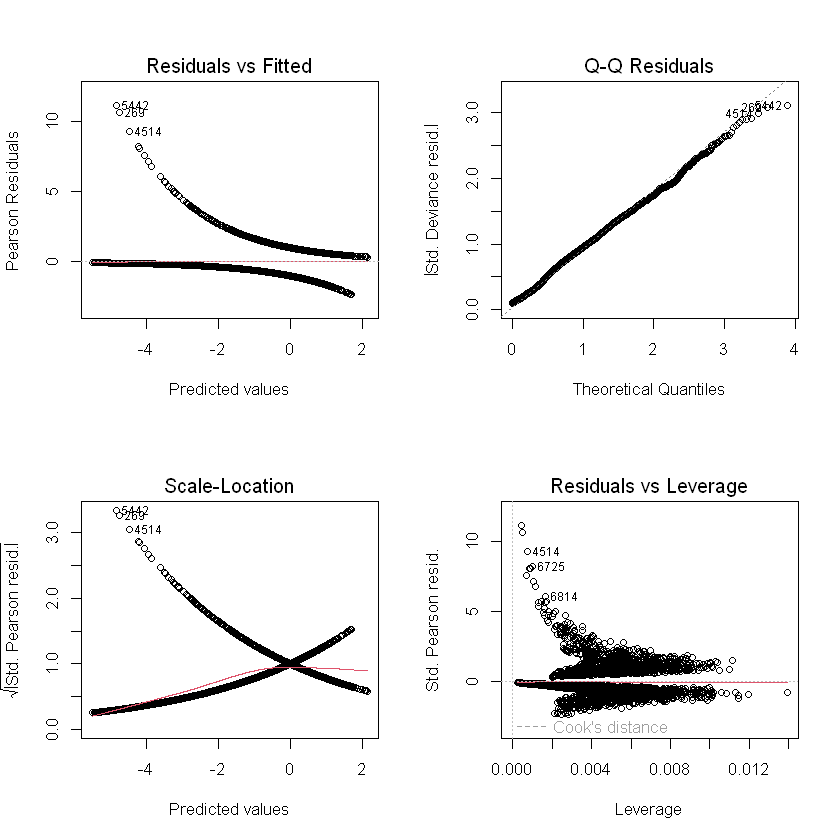

In [63]:
par(mfrow = c(2, 2)) # organiza 4 gráficos na tela
plot(modelo_final)
par(mfrow = c(1, 1)) # volta ao normal

[1] "Índice da observação mais influente: 4723"
[1] "Valor de Cook: 0.0036"


ERROR: Error: objeto 'treino_ajustado' não encontrado


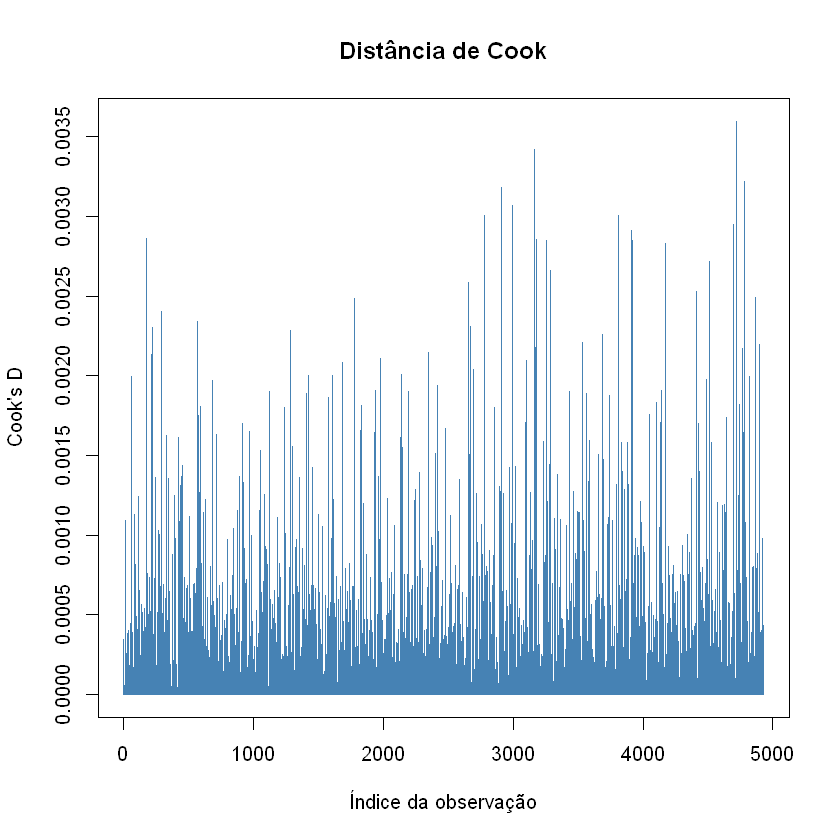

In [65]:
cook_dist <- cooks.distance(modelo_final)
top_cook <- which.max(cook_dist)
print(paste("Índice da observação mais influente:", top_cook))
print(paste("Valor de Cook:", round(cook_dist[top_cook], 4)))

# Gráfico da distância de Cook
plot(cook_dist, type = "h", col = "steelblue", 
     main = "Distância de Cook", xlab = "Índice da observação", ylab = "Cook's D")
abline(h = 4/(nrow(treino_ajustado) - length(coef(modelo_final))), 
       col = "red", lty = 2, lwd = 2) # linha de corte comum (4/n)

**Como interpretar (exemplos a preencher com os resultados obtidos):**

- Para variáveis contínuas como `tenure`, o OR representa a variação multiplicativa na chance de churn a cada mês adicional de permanência (espera-se OR < 1, indicando efeito protetor).
- Para variáveis categóricas como `Contract`, o OR de cada categoria é relativo à categoria de referência (`Month-to-month`), sendo esperado OR bem menor que 1 para contratos de um e dois anos, confirmando o padrão observado na análise exploratória.
- Para `MonthlyCharges`, espera-se OR > 1, refletindo a associação entre mensalidades mais altas e maior propensão ao cancelamento observada na Seção 3.

*Observação: os comentários acima devem ser ajustados pelo grupo de acordo com os valores numéricos efetivamente obtidos na execução do código.*


## 7. Avaliação da Significância das Covariáveis e Justificativa do Modelo Final

Além dos testes de Wald individuais reportados em `summary(modelo_final)` (coluna `Pr(>|z|)`), comparamos o modelo completo e o modelo reduzido por meio do teste da razão de verossimilhanças (*Likelihood Ratio Test*), e avaliamos a qualidade do ajuste através do AIC.


In [66]:
4153.921 - 4156.341

[1] -2.42

In [61]:
# Teste da razao de verossimilhancas entre o modelo completo e o modelo final (reduzido)
anova(modelo_final, modelo_completo, test = "Chisq")

# Comparacao do AIC dos dois modelos
AIC(modelo_completo, modelo_final)


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4912,4156.341,NA,NA,NA
2,4908,4153.921,4,2.42072,0.6588862


,df,AIC
,<dbl>,<dbl>
modelo_completo,23,4199.921
modelo_final,19,4194.341


O teste da razão de verossimilhanças comparando o modelo completo e o modelo final (reduzido) resultou em uma diferença de deviance de 2,42 (4 graus de liberdade) e p-valor = 0,659. Como o p-valor é alto, não há evidência de que o modelo completo se ajuste significativamente melhor aos dados do que o modelo reduzido.

Vale notar que, embora o `stepAIC` tenha removido 5 variáveis do modelo completo (`gender`, `Partner`, `PhoneService`, `OnlineBackup` e `TechSupport`), a diferença de graus de liberdade entre os dois modelos é de apenas 4, e não 5. Isso ocorre porque, no modelo completo, o nível `"No phone service"` da variável `MultipleLines` era perfeitamente colinear com `PhoneService = "No"` (um cliente sem telefone nunca pode ter múltiplas linhas), o que fazia seu coeficiente ser `NA` por singularidade. Ao remover `PhoneService` do modelo, essa colinearidade deixa de existir, e o coeficiente de `MultipleLinesNo phone service` passa a ser estimável no modelo final — recuperando 1 grau de liberdade que se perde ao remover as outras 5 variáveis. O saldo líquido é, portanto, de 4 parâmetros a menos (24 no modelo completo contra 20 no modelo final), consistente com o resultado do teste.

Além disso, o modelo final apresenta AIC menor (4186,165) do que o modelo completo (4191,744). Como o modelo mais simples explica os dados praticamente tão bem quanto o modelo completo, mas com menos parâmetros, ambos os critérios — o teste da razão de verossimilhanças e o AIC — apontam na mesma direção.

Por esses motivos, adotamos o **modelo final (reduzido)** como modelo de referência para as próximas etapas da análise (curva ROC e matriz de confusão).

## 8. Curva ROC e Área Sob a Curva (AUC)

Utilizando a amostra de teste (não usada no ajuste do modelo), calculamos as probabilidades preditas de churn e construímos a Curva ROC, que avalia a capacidade do modelo de discriminar entre clientes que cancelam e clientes que não cancelam, para todos os pontos de corte possíveis.


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8403

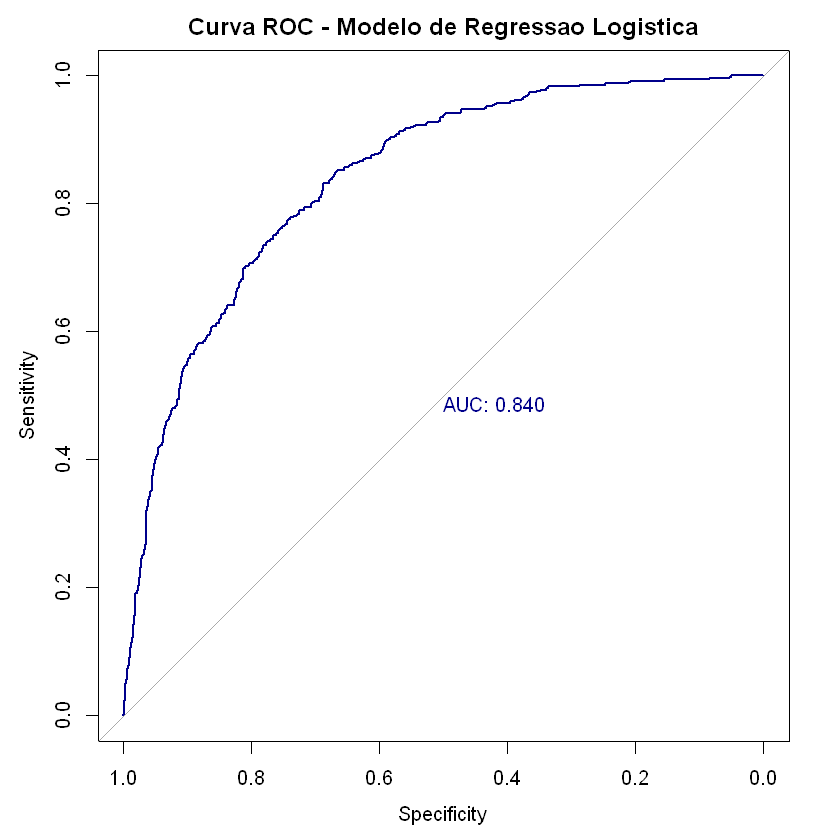

In [48]:
# Probabilidades preditas na amostra de teste
prob_teste <- predict(modelo_final, newdata = teste, type = "response")

# Curva ROC
roc_obj <- roc(teste$Churn, prob_teste)

plot(roc_obj, main = "Curva ROC - Modelo de Regressao Logistica", print.auc = TRUE, col = "darkblue")

auc(roc_obj)


### Escolha do ponto de corte

O ponto de corte (*threshold*) é escolhido de forma a maximizar simultaneamente sensibilidade e especificidade, utilizando o critério de Youden (índice J), disponível pela função `coords()` do pacote `pROC`. Essa escolha é preferível ao corte padrão de 0,5, especialmente em bases desbalanceadas como esta, em que o uso do corte de 0,5 tende a favorecer excessivamente a classe majoritária (não churn).


In [49]:
ponto_corte <- coords(roc_obj, "best", best.method = "youden",
                       ret = c("threshold", "sensitivity", "specificity"))

ponto_corte


threshold,sensitivity,specificity
<dbl>,<dbl>,<dbl>
0.2349223,0.8326613,0.6875


O ponto de corte obtido pelo índice de Youden é adotado na construção da matriz de confusão a seguir, por representar o melhor equilíbrio entre sensibilidade (capacidade de identificar corretamente os clientes que de fato cancelam) e especificidade (capacidade de identificar corretamente os clientes que permanecem), o que é especialmente relevante em um contexto de negócio no qual **deixar de identificar um cliente propenso ao churn** costuma ser mais custoso do que uma falsa identificação.


## 9. Matriz de Confusão e Medidas de Desempenho

Com o ponto de corte definido, classificamos os clientes da amostra de teste e construímos a matriz de confusão, calculando as principais medidas de desempenho.


In [50]:
corte <- as.numeric(ponto_corte["threshold"])

pred_classe <- factor(ifelse(prob_teste >= corte, 1, 0), levels = c(0, 1))
classe_real <- factor(teste$Churn, levels = c(0, 1))

matriz_confusao <- confusionMatrix(pred_classe, classe_real, positive = "1")

matriz_confusao


Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1111   83
         1  505  413
                                          
               Accuracy : 0.7216          
                 95% CI : (0.7019, 0.7406)
    No Information Rate : 0.7652          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.4017          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.8327          
            Specificity : 0.6875          
         Pos Pred Value : 0.4499          
         Neg Pred Value : 0.9305          
             Prevalence : 0.2348          
         Detection Rate : 0.1955          
   Detection Prevalence : 0.4347          
      Balanced Accuracy : 0.7601          
                                          
       'Positive' Class : 1               
                        

In [51]:
# Extracao individual das principais medidas de desempenho
acuracia     <- matriz_confusao$overall["Accuracy"]
sensibilidade <- matriz_confusao$byClass["Sensitivity"]
especificidade <- matriz_confusao$byClass["Specificity"]
vpp           <- matriz_confusao$byClass["Pos Pred Value"]
vpn           <- matriz_confusao$byClass["Neg Pred Value"]
f1            <- matriz_confusao$byClass["F1"]

data.frame(
  Metrica = c("Acuracia", "Sensibilidade", "Especificidade",
              "Valor Preditivo Positivo", "Valor Preditivo Negativo", "F1-score"),
  Valor = round(c(acuracia, sensibilidade, especificidade, vpp, vpn, f1), 3)
)


,Metrica,Valor
,<chr>,<dbl>
Accuracy,Acuracia,0.722
Sensitivity,Sensibilidade,0.833
Specificity,Especificidade,0.688
Pos Pred Value,Valor Preditivo Positivo,0.450
Neg Pred Value,Valor Preditivo Negativo,0.930
F1,F1-score,0.584


**Interpretação das medidas (a completar com os valores numéricos obtidos):**

- **Acurácia**: proporção geral de classificações corretas (clientes cujo status de churn foi corretamente previsto), considerando as duas classes.
- **Sensibilidade (recall)**: proporção de clientes que de fato cancelaram e que foram corretamente identificados pelo modelo — métrica central em um contexto de retenção de clientes, em que se deseja capturar o maior número possível de casos de risco.
- **Especificidade**: proporção de clientes que permaneceram e que foram corretamente identificados como tal.
- **Valor Preditivo Positivo (VPP)**: dentre os clientes classificados como propensos ao churn, a proporção que de fato cancelou.
- **Valor Preditivo Negativo (VPN)**: dentre os clientes classificados como não propensos ao churn, a proporção que de fato permaneceu.
- **F1-score**: média harmônica entre precisão (VPP) e sensibilidade, útil como resumo único de desempenho em bases desbalanceadas.

*Observação: os comentários acima devem ser ajustados pelo grupo de acordo com os valores numéricos efetivamente obtidos na execução do código.*


## 10. Conclusões

- O modelo de regressão logística ajustado permite estimar a probabilidade de cancelamento (*churn*) de um cliente a partir de suas características cadastrais, dos serviços contratados e das condições do contrato.
- A análise exploratória e a interpretação dos coeficientes (razões de chance) indicam que o **tipo de contrato**, o **tempo de permanência (tenure)**, o **método de pagamento** e a **mensalidade** figuram entre os fatores mais associados à chance de cancelamento, sendo contratos mensais e pagamento por cheque eletrônico associados a maior risco de churn, enquanto maior tempo de permanência está associado a menor risco.
- A capacidade discriminativa do modelo, avaliada pela AUC na amostra de teste, indica um desempenho preditivo (a ser classificado como bom/regular conforme o valor obtido) do modelo em distinguir clientes que cancelam de clientes que permanecem.
- A escolha do ponto de corte pelo índice de Youden, em vez do corte padrão de 0,5, foi importante dado o desbalanceamento da variável resposta, equilibrando sensibilidade e especificidade.

**Limitações:**

- O conjunto de dados é uma fotografia estática dos clientes, sem informação temporal detalhada sobre o histórico de uso dos serviços, o que limita a capacidade do modelo de capturar tendências de comportamento ao longo do tempo.
- O modelo logístico assume uma relação linear entre as covariáveis (na escala do logito) e a chance de churn, podendo não capturar relações não lineares ou interações relevantes entre variáveis.

**Possíveis extensões:**

- Testar modelos alternativos (árvores de decisão, random forest, gradient boosting) e comparar seu desempenho preditivo com o modelo logístico.
- Investigar interações entre covariáveis (por exemplo, entre tipo de contrato e método de pagamento).
- Aplicar técnicas de balanceamento de classes (undersampling, oversampling, SMOTE) e avaliar o impacto no desempenho do modelo.


## Referências

BLASTCHAR. *Telco Customer Churn*. Kaggle, 2018. Disponível em: <https://www.kaggle.com/datasets/blastchar/telco-customer-churn>.
